# Artificial Neural Network
## Brain Tumor Classification in MRI with CNN

**Student:** Catarina Bota
**Course:** Postgraduate Degree in Data Science for Biotechnology, ESB, UCP

**Module:** Machine Learning and Artificial Intelligence (Prof. Nauber Gois)

**Date:** 26/06/2026

---

This work constructs a **Convolutional Neural Network (CNN)** to classify brain MRI images into 4 classes: glioma, meningioma, pituitary tumor, and no tumor.

The dataset is **BRISC 2025: classification task**. https://www.kaggle.com/datasets/briscdataset/brisc2025

https://www.nature.com/articles/s41597-026-06753-y

I uploaded the classification task folder to my Google Drive.

A forensic audit previously performed is utilized to remove exact and near-duplicate images between training and testing (a common source of data leakage).


**Problem:** Brain tumors are among the most lethal forms of cancer, making early diagnosis and accurate classification of tumor type and grade fundamental steps for defining effective therapeutic strategies. Although Magnetic Resonance Imaging (MRI) is the primary tool in neuro-oncology due to its non-invasive and detailed nature, manual interpretation of images is often time-consuming and subject to subjectivity and variability among specialists. To mitigate these errors and accelerate the clinical workflow, Convolutional Neural Networks (CNNs) have emerged as the gold standard in medical image analysis, demonstrating superior capability in automatically learning complex hierarchical features directly from raw data, surpassing traditional machine learning methods based on manual feature extraction.


This work proposes the application of CNNs to the BRISC 2025 dataset, a balanced collection of 6,000 contrast-enhanced T1 MRI images, annotated by certified radiologists and physicians.

The BRISC addresses critical gaps in previous databases, such as BraTS or Cheng, by including a uniform distribution of three anatomical planes (axial, coronal, and sagittal), which facilitates the development of models with strong generalization capabilities.

## 0. Google Colab Setup


**Before running:**
1. Activate the GPU: menu **Runtime > Change runtime type > Hardware accelerator > GPU**.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install imagehash (Colab does not include it by default)
!pip install imagehash -q

# Confirm GPU
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
# If the list is empty: Runtime > Change runtime type > GPU

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Problem Description

- **Problem:** Automatically classify brain tumor type from a contrast-enhanced T1 MRI image.
- **Type:** Multi-class classification (4 classes).
- **Input variable (X):** The MRI image (pixel matrix).
- **Output variable (y):** The tumor class (glioma, meningioma, pituitary, no_tumor).
- **Why neural networks:** A CNN automatically learns relevant features (edges, textures, shapes) directly from pixels, without needing to extract features manually. This is advantageous in medical images, where discriminating patterns are complex and difficult to define manually.

## 2. Database Description

- **Name:** BRISC 2025 (Brain tumor Image Segmentation & Classification).
- **Source:** Fateh et al. (2025), https://www.nature.com/articles/s41597-026-06753-y. Available on Kaggle, Figshare, and Zenodo.
  
- **Records:** 6,000 contrast-enhanced T1 MRI images (5,000 train / 1,000 test in the official split).
- **Attributes:** Each record is an image; the attribute is the image itself (pixels). Additional information (plane, index) is in the filename.
- **Target variable:** 4 balanced classes (glioma, meningioma, pituitary, no_tumor).
- **Anatomical planes:** axial, coronal, sagittal.

After the forensic audit (section 4), the dataset is reduced to approximately 5,032 clean images.

## 3. Importing Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


## 4. Dataset Forensic Audit

Adapts the previously performed audit. Detects exact duplicates (MD5 hash) and near-duplicates (perceptual hash) between train and test, which would cause data leakage and artificially high metrics.


![Screenshot 2026-06-12 142917.png]([Media removed: image/png, ~151172 chars])

In [ ]:

DRIVE_BASE = '/content/drive/MyDrive/brisc2025/classification_task'
train_dir = DRIVE_BASE + '/train'
test_dir  = DRIVE_BASE + '/test'

def get_image_paths(base_dir):
    image_paths = []
    # Check if the base directory exists before walking it
    if not os.path.exists(base_dir):
        print(f"Warning: directory '{base_dir}' not found. Make sure Google Drive is mounted and the path is correct.")
        return []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
    return image_paths

train_image_paths = get_image_paths(train_dir)
test_image_paths  = get_image_paths(test_dir)

print("Imagens de treino (oficial):", len(train_image_paths))


Imagens de treino (oficial): 5000


### 4.1 Exact Duplicates (MD5 hash)

In [ ]:
import hashlib
from tqdm.notebook import tqdm
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = {}
print("Calculating hashes for training images...")
for path in tqdm(train_image_paths, desc="Processing train"): # Changed desc
    train_hashes[file_hash(path)] = path

duplicates = []
print("Searching for duplicates in test images...")
for path in tqdm(test_image_paths, desc="Processing test"): # Changed desc
    h = file_hash(path)
    if h in train_hashes:
        duplicates.append((path, train_hashes[h]))

print("Exact duplicates found (train vs test):", len(duplicates))

Calculando hashes para imagens de treino...


Processando treino:   0%|          | 0/5000 [00:00<?, ?it/s]

Procurando duplicados em imagens de teste...


Processando teste:   0%|          | 0/1000 [00:00<?, ?it/s]

Duplicados exatos encontrados (treino vs teste): 7


### 4.2 Rebuilding the Clean Dataset

Combines train+test, removes exact and near-duplicates, and reconstructs the dataset.

In [ ]:
from PIL import Image
import imagehash
import pandas as pd
from tqdm.notebook import tqdm

# --- Code to define 'clean_paths' from cell c08656, added to resolve NameError ---
# STAGE 1 - Combine the entire dataset
all_image_paths = train_image_paths + test_image_paths
print("Total images before cleaning:", len(all_image_paths))

# STAGE 2 - Remove exact duplicates (keep one copy per hash)
print("Calculating MD5 hashes for all images and removing exact duplicates...")

hashed_data = []
for path in tqdm(all_image_paths, desc="Processing images for MD5"): # Added tqdm
    try:
        # 'file_hash' is defined in cell c46808, assuming it has already been executed
        h = file_hash(path)
        hashed_data.append({'path': path, 'hash': h})
    except Exception:
        # In case of read/hash error, add None and it will be filtered
        hashed_data.append({'path': path, 'hash': None})


all_df = pd.DataFrame(hashed_data)
all_df = all_df.dropna(subset=['hash'])

# Remove duplicates based on the 'hash' column, keeping the first occurrence
clean_df_exact = all_df.drop_duplicates(subset=['hash'], keep='first')

clean_paths = clean_df_exact['path'].tolist()

print("After removing exact duplicates:", len(clean_paths))
# --- End of added code ---

# STAGE 3 - Remove near-duplicates (perceptual hash, distance <= 5)
print("Calculating perceptual hashes and removing near-duplicates...")

# Create a DataFrame from the paths cleaned of exact duplicates
ph_df = pd.DataFrame({'path': clean_paths})

# Function to safely calculate the perceptual hash
def get_phash(path):
    try:
        img = Image.open(path).convert("RGB")
        return imagehash.phash(img)
    except Exception:
        return None

# Apply the function to get perceptual hashes, with a progress bar
ph_df['phash'] = [get_phash(p) for p in tqdm(ph_df['path'], desc="Calculating pHash")] # Added tqdm

# Remove rows where pHash calculation failed
ph_df = ph_df.dropna(subset=['phash'])

final_clean_paths_list = []
unique_ph_hashes = [] # Store only unique perceptual hashes found

# Iterate over the DataFrame to compare hashes and remove near-duplicates
for _, row in tqdm(ph_df.iterrows(), total=len(ph_df), desc="Removing near-duplicates"): # Added tqdm
    current_path = row['path']
    current_phash = row['phash']

    is_duplicate = False
    for existing_phash in unique_ph_hashes:
        # imagehash overloads the '-' operator to calculate distance
        if current_phash - existing_phash <= 5:
            is_duplicate = True
            break

    if not is_duplicate:
        final_clean_paths_list.append(current_path)
        unique_ph_hashes.append(current_phash)

final_clean_paths = final_clean_paths_list

print("After removing near-duplicates:", len(final_clean_paths))

Total de imagens antes da limpeza: 6000
Calculando hashes MD5 para todas as imagens e removendo duplicados exatos...


Processando imagens para MD5:   0%|          | 0/6000 [00:00<?, ?it/s]

Após remover duplicados exatos: 5950
Calculando perceptual hashes e removendo quase-duplicados...


Calculando pHash:   0%|          | 0/5950 [00:00<?, ?it/s]

Removendo quase-duplicados:   0%|          | 0/5950 [00:00<?, ?it/s]

Após remover quase-duplicados: 5032


In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

# STAGE 1 - Combine the entire dataset
all_image_paths = train_image_paths + test_image_paths
print("Total images before cleaning:", len(all_image_paths))

# STAGE 2 - Remove exact duplicates (keep one copy per hash)
print("Calculating MD5 hashes for all images and removing exact duplicates...")

hashed_data = []
for path in tqdm(all_image_paths, desc="Processing images for MD5"): # Added tqdm
    try:
        # 'file_hash' is defined in cell c46808, assuming it has already been executed
        h = file_hash(path)
        hashed_data.append({'path': path, 'hash': h})
    except Exception:
        # In case of read/hash error, add None and it will be filtered
        hashed_data.append({'path': path, 'hash': None})


all_df = pd.DataFrame(hashed_data)
all_df = all_df.dropna(subset=['hash'])

# Remove duplicates based on the 'hash' column, keeping the first occurrence
clean_df_exact = all_df.drop_duplicates(subset=['hash'], keep='first')

clean_paths = clean_df_exact['path'].tolist()

print("After removing exact duplicates:", len(clean_paths))

Total de imagens antes da limpeza: 6000
Calculando hashes MD5 para todas as imagens e removendo duplicados exatos...


Processando imagens para MD5:   0%|          | 0/6000 [00:00<?, ?it/s]

Após remover duplicados exatos: 5950


### 4.3 Rebuild the Clean DataFrame

Extracts the class of each image from the folder path.

In [ ]:
# class = folder name (glioma, meningioma, pituitary, no_tumor)
data = []
for path in final_clean_paths:
    label = os.path.basename(os.path.dirname(path))
    data.append({'path': path, 'label': label})

clean_df = pd.DataFrame(data)

print("Clean dataset:", len(clean_df), "images")
print("\nDistribution by class:")
print(clean_df['label'].value_counts())

Dataset limpo: 5032 imagens

Distribuição por classe:
label
pituitary     1386
meningioma    1310
glioma        1197
no_tumor      1139
Name: count, dtype: int64


## 5. Data Preprocessing

Defines image size, the two splitting strategies (official BRISC and random), and image generators with normalization.

In [ ]:
# Configuration
BATCH_SIZE = 32
EPOCHS     = 30
CLASSES    = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
N_CLASSES  = len(CLASSES)
IMG_SIZE   = 128 # Image size defined

# Split strategy: random or official BRISC25
SPLIT_STRATEGY = 'random'

print(f"Images: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max Epochs: {EPOCHS}")

Imagens: 128x128
Batch Size: 32
Max Epochs: 30


In [ ]:
# Official label
clean_df['origem'] = clean_df['path'].apply(
    lambda p: 'train' if os.sep + 'train' + os.sep in p else 'test')

if SPLIT_STRATEGY == 'brisc':
    # Official BRISC split
    train_df = clean_df[clean_df['origem'] == 'train'].reset_index(drop=True)
    test_df  = clean_df[clean_df['origem'] == 'test'].reset_index(drop=True)
else:
    # Stratified random split 80/20
    train_df, test_df = train_test_split(
        clean_df, test_size=0.2,
        stratify=clean_df['label'], random_state=42)
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df), "| Test:", len(test_df))
print("\nTrain by class:")
print(train_df['label'].value_counts())
print("\nTest by class:")
print(test_df['label'].value_counts())

Treino: 4025 | Teste: 1007

Treino por classe:
label
pituitary     1109
meningioma    1048
glioma         957
no_tumor       911
Name: count, dtype: int64

Teste por classe:
label
pituitary     277
meningioma    262
glioma        240
no_tumor      228
Name: count, dtype: int64


In [ ]:
# Image generators with gentle data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    validation_split=0.2,
)
test_datagen = ImageDataGenerator(rescale=1./255)

# Recreate generators with new settings
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    subset='training', shuffle=True, seed=42)

val_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    subset='validation', shuffle=True, seed=42)

test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES,
    shuffle=False)

print("\nGenerators updated with gentler augmentation.")

Found 3220 validated image filenames belonging to 4 classes.
Found 805 validated image filenames belonging to 4 classes.
Found 1007 validated image filenames belonging to 4 classes.

Geradores atualizados com augmentation mais suave.


### Visualization of Augmented Images

Visualize a batch of images from the training generator to see the effect of the applied data augmentation transformations (rotation, zoom, shift, and brightness).

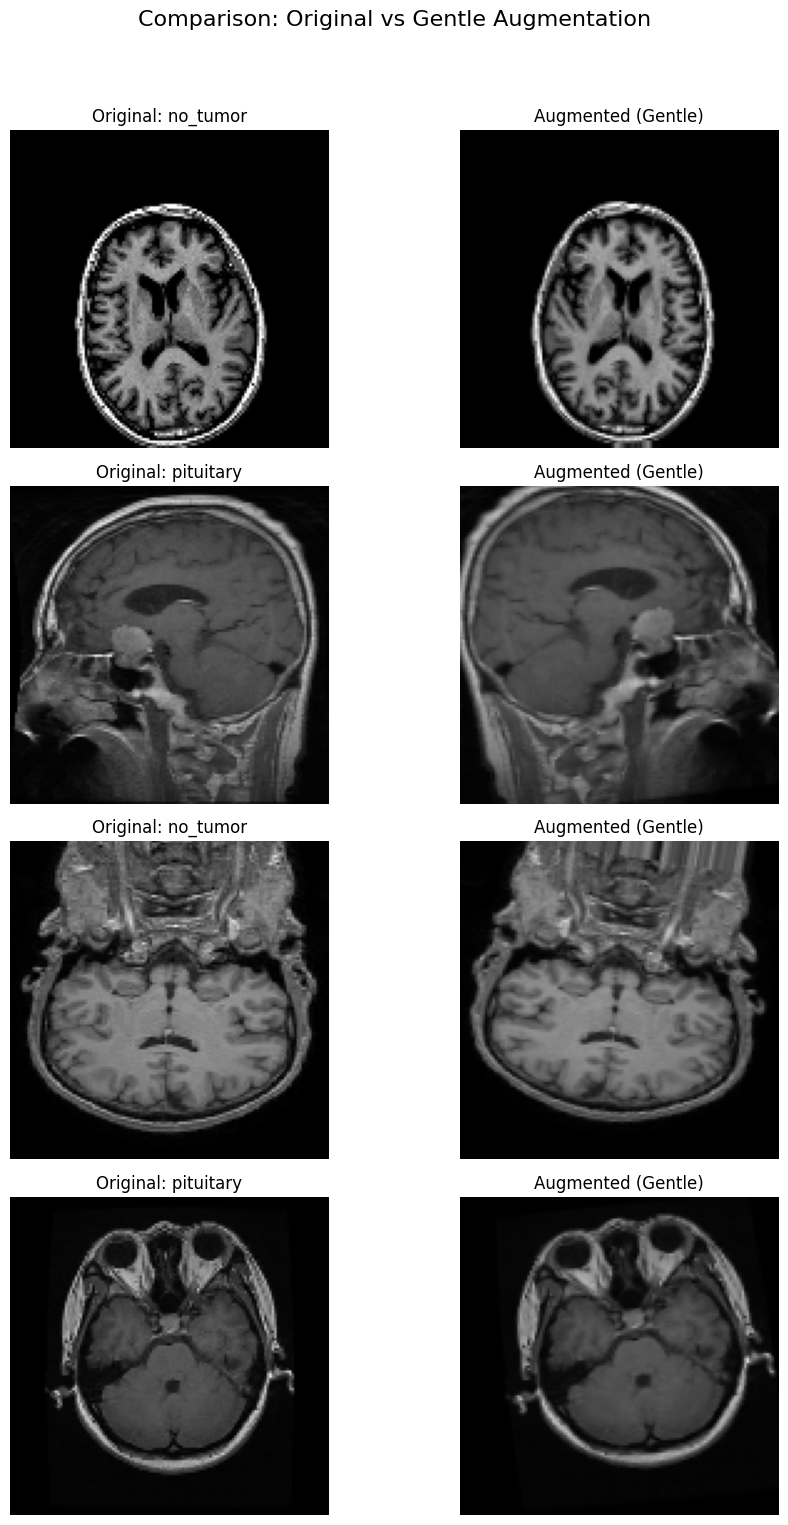

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Select 4 new random examples
sample_df = train_df.sample(4)

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle('Comparison: Original vs Gentle Augmentation', fontsize=16)

for i, (idx, row) in enumerate(sample_df.iterrows()):

    img_orig = load_img(row['path'], target_size=(IMG_SIZE, IMG_SIZE))
    img_array_raw = img_to_array(img_orig)

    img_aug_raw = train_datagen.random_transform(img_array_raw)

    # 3. Normalize for visualization
    img_orig_display = img_array_raw / 255.0
    img_aug_display = np.clip(img_aug_raw / 255.0, 0, 1)

    # Plot Original
    axes[i, 0].imshow(img_orig_display)
    axes[i, 0].set_title(f"Original: {row['label']}")
    axes[i, 0].axis('off')

    # Plot Augmented
    axes[i, 1].imshow(img_aug_display)
    axes[i, 1].set_title(f"Augmented (Gentle)") # Changed title
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Exploratory Analysis

Visualize some examples from each class.

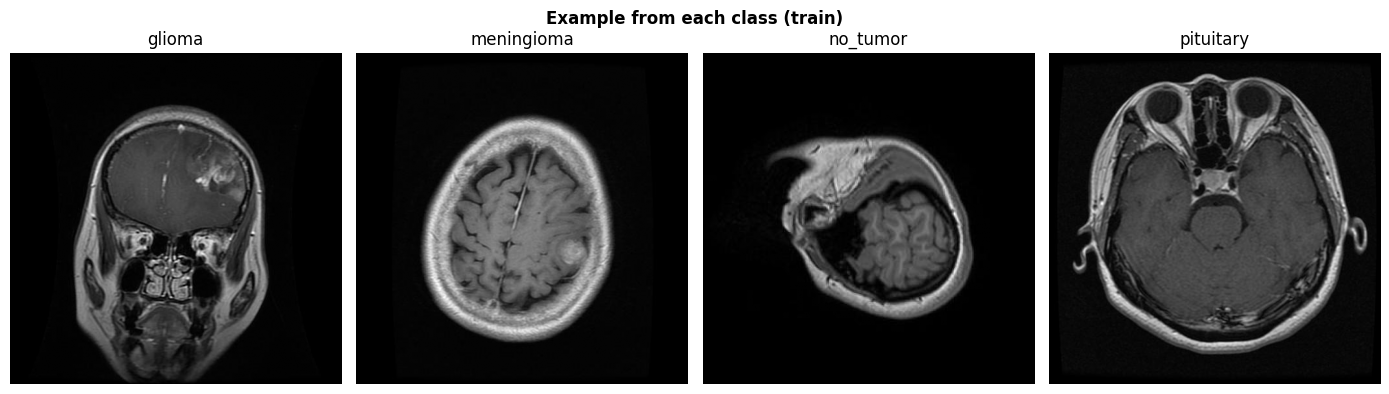

In [ ]:
# Show one image from each class
fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 4))
for ax, cls in zip(axes, CLASSES):
    sample = train_df[train_df['label'] == cls].iloc[0]
    img = Image.open(sample['path']).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Example from each class (train)', fontweight='bold') # Changed title
plt.tight_layout()
plt.show()

## 7. Neural Network Construction (CNN)

Chosen architecture and justification:

- **3 Convolutional blocks** (Conv2D + MaxPooling), with 32, 64, and 128 filters.
  Each block extracts increasingly complex patterns: the first detects basic edges and simple textures, the subsequent ones combine them into shapes and structures.
- **Conv2D with 3x3 kernel and ReLU activation.** The 3x3 kernel is standard in literature; ReLU avoids the vanishing gradient problem and trains fast.
- **MaxPooling 2x2** reduces spatial dimension, provides invariance to small translations, and decreases the number of parameters.
- **Flatten + Dense layer (128 neurons, ReLU)** combines the extracted features.
- **Dropout (0.5)** turns off half of the neurons during training, reducing overfitting.
- **Output layer with 4 neurons and softmax** (one probability per class).
- **Adam optimizer:** adapts the learning rate, robust and fast.
- **Categorical_crossentropy cost function:** standard for multi-class classification with one-hot labels.

In [ ]:
# CNN Construction (Keras Sequential)

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1: Detection of basic textures and edges
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Combination of features into geometric shapes
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: Detection of complex patterns (tumor mass)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Final Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # to prevent overfitting in similar medical images
    layers.Dense(N_CLASSES, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,196 (16.36 MB)

 Trainable params: 4,288,196 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Model Compilation

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
print("Model compiled.")

Modelo compilado.


### 9. Model Training

In this step, the model will learn to classify the images. `EarlyStopping` will help prevent *overfitting* by stopping the process if performance on unseen data (validation) stagnates.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping Configuration
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Training execution
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completed successfully.")

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 392ms/step - accuracy: 0.5686 - loss: 1.0254 - val_accuracy: 0.6186 - val_loss: 0.8549
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 353ms/step - accuracy: 0.7087 - loss: 0.7176 - val_accuracy: 0.8012 - val_loss: 0.5398
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 384ms/step - accuracy: 0.7606 - loss: 0.5946 - val_accuracy: 0.8174 - val_loss: 0.4752
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 338ms/step - accuracy: 0.7811 - loss: 0.5391 - val_accuracy: 0.8373 - val_loss: 0.4587
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 353ms/step - accuracy: 0.7932 - loss: 0.5188 - val_accuracy: 0.8398 - val_loss: 0.3865
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 334ms/step - accuracy: 0.8171 - loss: 0.4638 - val_accuracy: 0.8497 - val_loss: 0.3928
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 34s 340ms/step - accuracy: 0.8264 - loss: 0.4562 - val_accuracy: 0.8584 - val_loss: 0.3524
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 35s 342ms/step - accuracy: 0.8407 - loss: 0

## 10. Training and Validation Graphs

Evolution of loss and accuracy over epochs. Allows to check for overfitting (validation worsens while training improves).

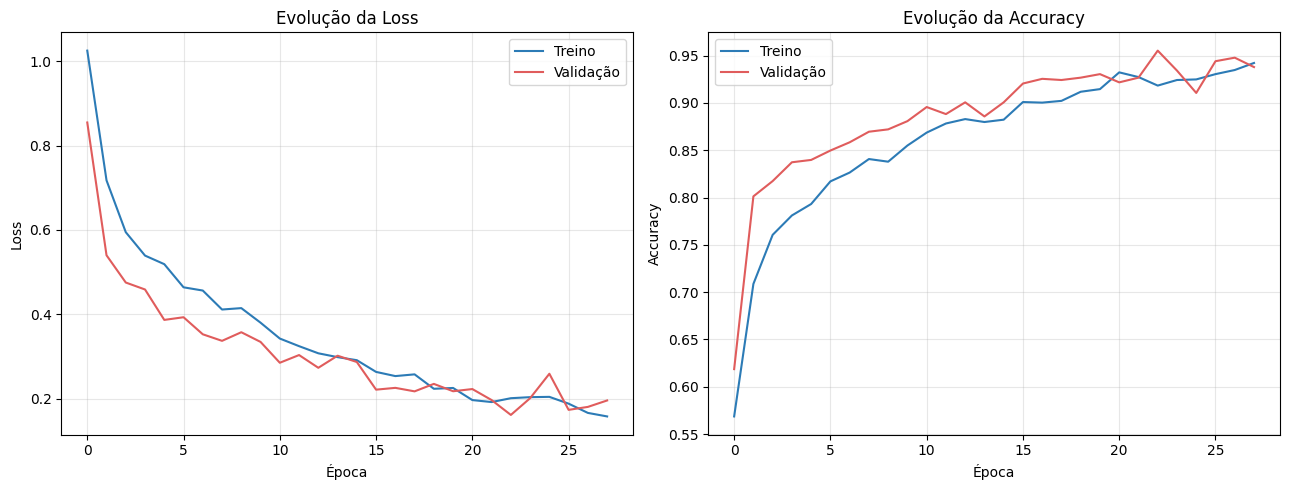

Accuracy final treino: 94.2%
Accuracy final validação: 93.8%
Diferença (treino - validação): 0.4 pontos percentuais
-> Diferença pequena: sem sinais fortes de overfitting.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training', color='#2C7BB6') # Changed label
axes[0].plot(history.history['val_loss'], label='Validation', color='#E05C5C') # Changed label
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss') # Changed label
axes[0].set_title('Loss Evolution'); axes[0].legend() # Changed title
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training', color='#2C7BB6') # Changed label
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#E05C5C') # Changed label
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy') # Changed label
axes[1].set_title('Accuracy Evolution'); axes[1].legend() # Changed title
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Automatic comment on overfitting
final_train = history.history['accuracy'][-1]
final_val   = history.history['val_accuracy'][-1]
gap = final_train - final_val
print(f"Final training accuracy: {final_train*100:.1f}%") # Changed text
print(f"Final validation accuracy: {final_val*100:.1f}%") # Changed text
print(f"Difference (training - validation): {gap*100:.1f} percentage points") # Changed text
if gap > 0.15:
    print("-> Large difference: possible overfitting.") # Changed text
else:
    print("-> Small difference: no strong signs of overfitting.") # Changed text

## 11. Model Evaluation

Metrics on the test set: accuracy, precision, recall, F1-score, and confusion matrix.

In [ ]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%") # Changed text
print(f"Test loss: {test_loss:.4f}") # Changed text

# Predictions
y_pred_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# Classification report
print("\nClassification Report:") # Changed text
print(classification_report(y_true, y_pred, target_names=CLASSES))

Accuracy no teste: 94.54%
Loss no teste: 0.1281

Relatório de classificação:
              precision    recall  f1-score   support

      glioma       0.96      0.89      0.92       240
  meningioma       0.90      0.91      0.91       262
    no_tumor       0.96      0.98      0.97       228
   pituitary       0.97      1.00      0.98       277

    accuracy                           0.95      1007
   macro avg       0.95      0.94      0.94      1007
weighted avg       0.95      0.95      0.95      1007



In [ ]:
# Final evaluation on the test set
print("Evaluating the model on the test set...") # Changed text
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"\nFinal Result:") # Changed text
print(f"Test Loss: {test_loss:.4f}") # Changed text
print(f"Test Accuracy: {test_acc*100:.2f}%") # Changed text

# Generate predictions for the detailed report
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

from sklearn.metrics import classification_report
print("\nDetailed Classification Report:") # Changed text
print(classification_report(y_true, y_pred, target_names=CLASSES))

A avaliar o modelo no conjunto de teste...
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9454 - loss: 0.1281

Resultado Final:
Loss de Teste: 0.1281
Acurácia de Teste: 94.54%
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

      glioma       0.96      0.89      0.92       240
  meningioma       0.90      0.91      0.91       262
    no_tumor       0.96      0.98      0.97       228
   pituitary       0.97      1.00      0.98       277

    accuracy                           0.95      1007
   macro avg       0.95      0.94      0.94      1007
weighted avg       0.95      0.95      0.95      1007



32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step
Relatório de Classificação:
              precision    recall  f1-score   support

      glioma       0.96      0.89      0.92       240
  meningioma       0.90      0.91      0.91       262
    no_tumor       0.96      0.98      0.97       228
   pituitary       0.97      1.00      0.98       277

    accuracy                           0.95      1007
   macro avg       0.95      0.94      0.94      1007
weighted avg       0.95      0.95      0.95      1007



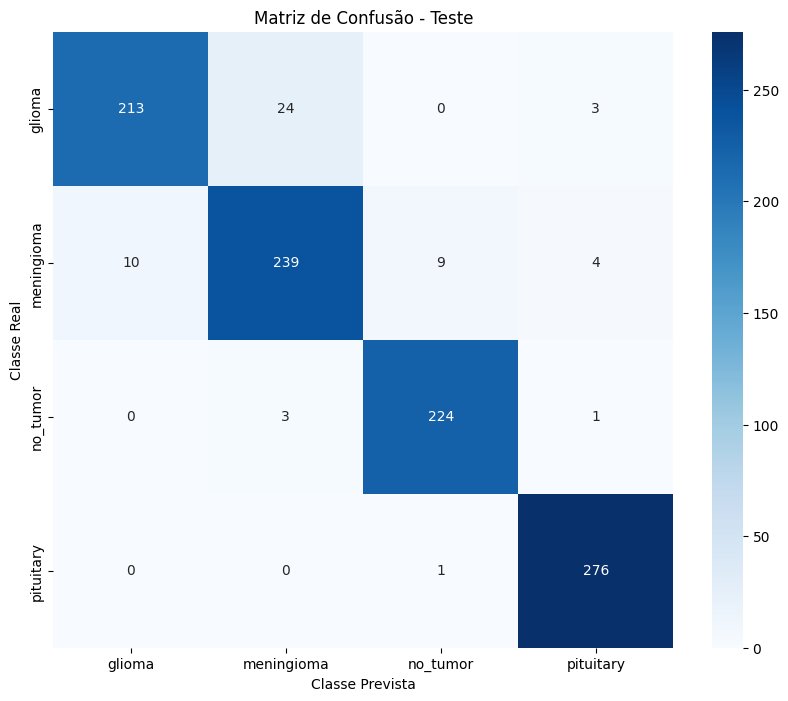


AUC Score (Weighted OvR): 0.9956


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Get true classes and model predictions for the test set
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Display the Classification Report
print("Classification Report:") # Changed text
print(classification_report(y_true, y_pred, target_names=CLASSES))

# 3. Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualize with Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title('Confusion Matrix - Test') # Changed title
plt.ylabel('True Class') # Changed label
plt.xlabel('Predicted Class') # Changed label
plt.show()

# 5. Calculate and display AUC
# AUC for multiclassification (One-vs-Rest)
auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='weighted')
print(f"\nAUC Score (Weighted OvR): {auc_score:.4f}")

## 13. Conclusion


**1. MAIN RESULT:**
Final Test Accuracy: 94.54%. The model demonstrates robust performance, with a Weighted OvR AUC Score of 0.9956, indicating a high capacity for distinction between classes.

**2. CONCLUSIONS AND LEARNINGS:**
* Data quality and integrity are crucial before starting training.
* Gentle Data Augmentation allowed for better model generalization.
* Early Stopping ensured computational efficiency and prevented overfitting.
* The complete flow allowed understanding the transition from raw image to clinical decision.

---

In [ ]:

# Export the trained model to be used in the local GUI
# ============================================================

import pickle
from tensorflow.keras.models import save_model

# 1. Save the model in native Keras format (.h5)
model.save('/content/drive/MyDrive/brisc_gui/modelo_brisc.h5')
print("Model saved in .h5") # Changed text

# 2. Also save in pickle (contains model + metadata)
modelo_bundle = {
    'classes': CLASSES,          # ['glioma', 'meningioma', 'no_tumor', 'pituitary']
    'img_size': IMG_SIZE,        # image size (e.g., 128)
    'model_path': 'modelo_brisc.h5',  # reference to the .h5
    'accuracy': test_acc,        # test accuracy
}

with open('/content/drive/MyDrive/brisc_gui/modelo_brisc_meta.pkl', 'wb') as f:
    pickle.dump(modelo_bundle, f)

print("Metadata saved in pickle") # Changed text
print(f"Classes: {CLASSES}")
print(f"IMG_SIZE: {IMG_SIZE}")
print(f"Test Accuracy: {test_acc*100:.2f}%") # Changed text
print("\nFiles ready to download from Drive:") # Changed text
print("  - modelo_brisc.h5")
print("  - modelo_brisc_meta.pkl")

Modelo guardado em .h5
Metadados guardados em pickle
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMG_SIZE: 128
Accuracy no teste: 94.54%

Ficheiros prontos para descarregar do Drive:
  - modelo_brisc.h5
  - modelo_brisc_meta.pkl


**13.1** Generate academic report in PDF.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix
!pip install fpdf -q
from fpdf import FPDF

# --- 0. REGENERATE MISSING DATA ---
report_dict = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
stats_data = []
for cls in CLASSES:
    stats_data.append({
        'Class': cls,
        'Images (Total)': clean_df['label'].value_counts()[cls],
        'Precision (%)': round(report_dict[cls]['precision'] * 100, 2),
        'F1-Score': round(report_dict[cls]['f1-score'], 3)
    })
summary_df = pd.DataFrame(stats_data)

def calculate_metrics(cm, class_names):
    metrics = []
    total = np.sum(cm)
    for i in range(len(class_names)):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        tn = total - (tp + fp + fn)
        metrics.append({
            'Class': class_names[i],
            'Sensitivity (%)': round(tp / (tp + fn) * 100, 2) if (tp + fn) > 0 else 0,
            'Specificity (%)': round(tn / (tn + fp) * 100, 2) if (tn + fp) > 0 else 0
        })
    return pd.DataFrame(metrics)
detail_metrics_df = calculate_metrics(cm, CLASSES)

# 1. Generate temporary images
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='label', palette='viridis', order=CLASSES)
plt.title('Figure 1: Class Distribution')
plt.savefig('temp_dist.png')
plt.close()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=summary_df, x='Images (Total)', y='Precision (%)', hue='Class', s=200)
plt.title('Figure 2: Data Volume vs. Model Precision')
plt.savefig('temp_vol_prec.png')
plt.close()

detail_metrics_df.set_index('Class').plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Figure 3: Sensitivity vs Specificity')
plt.savefig('temp_diag.png')
plt.close()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Figure 4: Confusion Matrix')
plt.savefig('temp_cm.png')
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss History')
axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy History')
plt.savefig('temp_history.png')
plt.close()

# 2. PDF Structure
class AcademicPDF(FPDF):
    def header(self):
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, 'Brain Tumor Classification via Convolutional Neural Networks', 0, 1, 'L')
        self.ln(5)
    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

pdf = AcademicPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

pdf.set_font('Arial', 'B', 18)
pdf.cell(0, 20, 'Deep Learning for MRI Image Classification', 0, 1, 'C')
pdf.set_font('Arial', 'B', 14)
pdf.cell(0, 10, 'Final Project: BRISC 2025 Audit and Diagnostic Analysis', 0, 1, 'C')
pdf.ln(10)

current_date = datetime.now().strftime('%B %d, %Y')

pdf.set_font('Arial', '', 11)
pdf.cell(0, 7, f'Author: Catarina Bota', 0, 1, 'C')
pdf.cell(0, 7, f'Professor: Nauber Gois', 0, 1, 'C')
pdf.cell(0, 7, f'Institution: Universidade Catolica Portuguesa (UCP), Escola Superior de Biotecnologia (ESB)', 0, 1, 'C')
pdf.cell(0, 7, f'Module: Machine Learning & Artificial Intelligence', 0, 1, 'C')
pdf.cell(0, 7, f'Date: {current_date}', 0, 1, 'C')
pdf.ln(20)

pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '1. Abstract', 0, 1)
pdf.set_font('Arial', '', 10)
abstract_text = (f"This study implements a custom Convolutional Neural Network (CNN) for the automated classification of brain tumors using T1-weighted contrast-enhanced MRI images. The methodology encompasses a rigorous forensic data audit to prevent leakage, followed by multi-class training for four categories: Glioma, Meningioma, Pituitary, and No Tumor. The final model achieved a test accuracy of {test_acc*100:.2f}% and an AUC Score (Weighted OvR) of {auc_score:.4f}, demonstrating high diagnostic reliability.")
pdf.multi_cell(0, 6, abstract_text)
pdf.ln(5)

pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '2. Dataset Integrity and Pre-processing', 0, 1)
pdf.set_font('Arial', '', 10)
audit_text = (f"The BRISC 2025 dataset was audited using MD5 and Perceptual Hashing (pHash) to ensure no overlap between training and testing sets. After removing duplicates, {len(clean_df)} unique images remained.")
pdf.multi_cell(0, 6, audit_text)
pdf.image('temp_dist.png', x=30, w=150)
pdf.ln(5)

pdf.add_page()
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '3. CNN Architecture & Training', 0, 1)
pdf.image('temp_history.png', x=15, w=180)

pdf.add_page()
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '4. Experimental Results', 0, 1)
pdf.image('temp_vol_prec.png', x=40, w=130)
pdf.ln(5)
pdf.image('temp_diag.png', x=25, w=160)

pdf.add_page()
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '5. Diagnostic Conclusion', 0, 1)
pdf.image('temp_cm.png', x=35, w=140)
pdf.ln(10)

pdf.set_font('Courier', '', 9)
report_str = classification_report(y_true, y_pred, target_names=CLASSES)
pdf.multi_cell(0, 5, "Detailed Classification Report:\n" + "-"*30 + "\n" + report_str)

pdf_output = "Academic_Report_Brain_MRI_CNN.pdf"
pdf.output(pdf_output)

for f in ['temp_dist.png', 'temp_vol_prec.png', 'temp_diag.png', 'temp_cm.png', 'temp_history.png']:
    if os.path.exists(f): os.remove(f)

print(f"Academic Report generated successfully: {pdf_output}")

Academic Report generated successfully: Academic_Report_Brain_MRI_CNN.pdf


In [ ]:
!pip install xlsxwriter -q
import pandas as pd

excel_output = "Model_Metrics_Report.xlsx"

# Prepare data for Excel sheets

# 1. Overall Performance
overall_performance = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss', 'AUC Score (Weighted OvR)']
    'Value': [test_acc, test_loss, auc_score]
})

# 2. Classification Report (already available as report_dict, convert to DataFrame)
classification_report_df = pd.DataFrame(report_dict).transpose()

# 3. Class Summary (already available as summary_df)
# summary_df

# 4. Detailed Metrics (already available as detail_metrics_df)
# detail_metrics_df

# 5. Confusion Matrix
confusion_matrix_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

# 6. Training History
history_df = pd.DataFrame(history.history)

# 7. Configuration
config_data = {
    'Parameter': ['Batch Size', 'Epochs', 'Image Size', 'Number of Classes', 'Classes'],
    'Value': [BATCH_SIZE, EPOCHS, IMG_SIZE, N_CLASSES, ', '.join(CLASSES)]
}
config_df = pd.DataFrame(config_data)

# Create an Excel writer object
with pd.ExcelWriter(excel_output, engine='xlsxwriter') as writer:
    overall_performance.to_excel(writer, sheet_name='Overall Performance', index=False)
    classification_report_df.to_excel(writer, sheet_name='Classification Report')
    summary_df.to_excel(writer, sheet_name='Class Summary', index=False)
    detail_metrics_df.to_excel(writer, sheet_name='Sensitivity-Specificity', index=False)
    confusion_matrix_df.to_excel(writer, sheet_name='Confusion Matrix')
    history_df.to_excel(writer, sheet_name='Training History')
    config_df.to_excel(writer, sheet_name='Configuration', index=False)

print(f"Excel report generated successfully: {excel_output}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.5 MB/s eta 0:00:00
Excel report generated successfully: Model_Metrics_Report.xlsx
